# 0.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import os
import sys
import matplotlib.pyplot as plt
import matplotlib as mpl
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42

In [2]:
import sys
sys.path.insert(0, '/home/xtsong/Algos/StrInt')

In [3]:
from pyStrint import plotting as pl
from pyStrint import preprocess as pp
from pyStrint import evaluation as eva
from pyStrint import utils
# reload pp
import importlib
importlib.reload(pp)

<module 'pyStrint.preprocess' from '/home/xtsong/Algos/StrInt/pyStrint/preprocess.py'>

In [4]:

# --- injected compatibility/setup cell ---
import os
import pandas as pd
import numpy as np

BASE = '/bigdata/disk2/xtsong-data/strint/SCC_results'
ANA = f'{BASE}/ana'
os.makedirs(f'{ANA}/figures', exist_ok=True)
os.makedirs(f'{ANA}/saved', exist_ok=True)

spex_inputDir = BASE
Raw_inputDir = f'{BASE}/inputs'
outDir = f'{BASE}/ana/saved'

def _read_auto(fp):
    if fp.endswith('.tsv'):
        return pd.read_csv(fp, sep='	')
    return pd.read_csv(fp)

def load_alphatalk_major(adata, lr_fp, cci_dir):
    df = _read_auto(lr_fp).copy()
    # Prefer major-map columns when available (14 major cell types)
    if 'sender_major' in df.columns:
        df['celltype_sender'] = df['sender_major']
    elif 'cell_sender' in df.columns:
        df['celltype_sender'] = df['cell_sender']

    if 'receiver_major' in df.columns:
        df['celltype_receiver'] = df['receiver_major']
    elif 'cell_receiver' in df.columns:
        df['celltype_receiver'] = df['cell_receiver']
    if 'co_exp_number' in df.columns and 'lr_co_exp_num' not in df.columns:
        df['lr_co_exp_num'] = df['co_exp_number']
    if 'LRI' not in df.columns and {'ligand','receptor'}.issubset(df.columns):
        df['LRI'] = df['ligand'].astype(str) + '|' + df['receptor'].astype(str)
    if 'cell_pair' not in df.columns and {'celltype_sender','celltype_receiver'}.issubset(df.columns):
        df['cell_pair'] = df['celltype_sender'].astype(str) + '->' + df['celltype_receiver'].astype(str)
    adata.uns['spatalk'] = df

    rec = pd.read_csv(f'{cci_dir}/rec_per_major.tsv', sep='	', index_col=0)
    send = pd.read_csv(f'{cci_dir}/send_per_major.tsv', sep='	', index_col=0)
    nn = pd.read_csv(f'{cci_dir}/celltype_nn_major.tsv', sep='	')
    adata.uns['rec_per'] = rec
    adata.uns['send_per'] = send
    adata.uns['celltype_nn'] = nn

    cp = df.copy()
    cp['sender_tp'] = cp['celltype_sender']
    cp['receiver_tp'] = cp['celltype_receiver']
    cp['Name'] = cp['sender_tp'].astype(str) + ' -- ' + cp['receiver_tp'].astype(str)
    adata.uns['cellpair'] = cp
    adata.uns['tp_key'] = 'celltype_major'



spex_inputDir = '/bigdata/disk2/xtsong-data/strint/SCC_results/refined'
Raw_inputDir = '/bigdata/disk2/xtsong-data/strint/SCC_results/inputs'
outDir = '/bigdata/disk2/xtsong-data/strint/SCC_results/ana/figures'
import os
os.makedirs('/bigdata/disk2/xtsong-data/strint/SCC_results/ana/figures', exist_ok=True)
os.makedirs('/bigdata/disk2/xtsong-data/strint/SCC_results/ana/saved', exist_ok=True)


In [5]:
spex_inputDir = '/bigdata/disk2/xtsong-data/strint/SCC_results/refined'
Raw_inputDir = '/bigdata/disk2/xtsong-data/strint/SCC_results/inputs'
outDir = '/bigdata/disk2/xtsong-data/strint/SCC_results'

In [6]:
palette_dict = {'Original':'#ef8a62','Refined':'#67a9cf','ST':"#C798EE"}

major_color_map = {'Myeloid':'#EC7063',
 'Endo':'#22a8a1',
 'KC':'#28B463',
 'KC (Cyc)':'#63C1A3',
 'KC (Diff)':'#59BE86',
 'KC (Basal)':'#76D7C4',
 'FB':"#3A84E6",
 'LC':'#3498DB',
 'T cell':'#E88AC2',
 'Epithelial':'#9DB0D4',
 'TSK':'#E74C3C',
 'B cell':'#ffb200',
 'Melanocyte':'#85C1E9',
 'NK':'#C798EE'}

color_map = {'ASDC': '#E74C3C',
 'MDSC':'#F56867',
 'B_Cell': '#D35400',
'B Cell': '#D35400',
 'CD1C': '#EC7063',
 'CD4_Naive': '#DC7633',
 'CD4_Pre_Exh': '#D95F02',
 'CD8_EM': '#ffb200',
 'CD8_Exh': '#ed5eb3',
 'CLEC9A': '#F5B7B1',
 'Eccrine': '#1B9E77',
 'Endothelial_Cell': '#28B463',
  'Endothelial Cell': '#28B463',
 'Fibroblast': '#85C1E9',
 'Keratinocyte': '#58D68D',
 'LC': '#22a8a1',
 'Mac': '#EC7063',
 'Melanocyte': '#2B83BA',
 'Mig_CD1C': '#007FFF',
 'Mig_CLEC9A': '#3498DB',
 'Mig_LC': '#00c9ff',
 'NK': '#8cc63f',
 'PDC': '#9DB0D4',
 'Pilosebaceous': '#5E3C99',
 'TSK': '#EC7063',
 'Treg': '#22a8a1',
 'Tumor_KC_Basal': '#AF7AC5',
 'Tumor_KC_Cyc': '#D2B4DE',
 'Tumor_KC_Diff': '#E88AC2'}

minor_map = {'CLEC9A': 'Myeloid',
 'Endothelial_Cell': 'Endo',
 'Endothelial Cell': 'Endo',
 'CD1C': 'Myeloid',
 'Keratinocyte': 'KC',
 'Tumor_KC_Cyc': 'KC (Cyc)',
 'Fibroblast': 'FB',
 'LC': 'LC',
 'Mig_CD1C': 'Myeloid',
 'Mac': 'Myeloid',
 'Tumor_KC_Basal': 'KC (Basal)',
 'ASDC': 'Myeloid',
 'CD8_Exh': 'T cell',
 'Pilosebaceous': 'Epithelial',
 'Tumor_KC_Diff': 'KC (Diff)',
 'PDC': 'Myeloid',
 'Mig_LC': 'LC',
 'Treg': 'T cell',
 'TSK': 'TSK',
 'MDSC': 'Myeloid',
 'Eccrine': 'Epithelial',
 'B_Cell': 'B cell',
  'B Cell': 'B cell',
 'Melanocyte': 'Melanocyte',
 'CD8_EM': 'T cell',
 'CD4_Naive': 'T cell',
 'CD4_Pre_Exh': 'T cell',
 'Mig_CLEC9A': 'Myeloid',
 'NK': 'NK'}

In [7]:
species = 'Human'
new_exp_fn = f'{spex_inputDir}/refined_sc_exp.tsv'
new_meta_fn = f'{spex_inputDir}/cell_mapping_meta.tsv'

alter_exp = pd.read_csv(new_exp_fn,sep='\t',index_col=0,header=0)
sc_agg_meta = pd.read_csv(new_meta_fn,sep='\t',index_col=0,header=0)
sc_agg_meta['adj_spex_UMAP2'] = sc_agg_meta['adj_spex_UMAP2']*-1
sc_agg_meta['st_y'] = sc_agg_meta['st_y']*-1

In [8]:
refine_adata = pp.make_adata(alter_exp,sc_agg_meta,species,save_path = outDir, save_adata = False)
refine_adata.obs['celltype_major'] = refine_adata.obs['celltype'].map(minor_map)
refine_adata._uns['tp_key'] = 'celltype_major'
refine_adata._uns['major_color_map'] = major_color_map

AnnData object created:
  - Cells: 7144
  - Genes: 10659
  - Species: Human


In [9]:
# set Rscript path
rscript_path = utils.find_executable_in_path('Rscript')
refine_adata.uns['rscript_path'] = rscript_path if rscript_path else 'Not found Rscript'
# set Python path
python_path = sys.executable
refine_adata.uns['python_path'] = python_path

print(f"Rscript: {refine_adata.uns['rscript_path']}")
print(f"Python: {refine_adata.uns['python_path']}")

Rscript: /home/xtsong/miniforge3/envs/strint_3/bin/Rscript
Python: /home/xtsong/miniforge3/envs/strint_3/bin/python


In [10]:
refine_adata

AnnData object with n_obs × n_vars = 7144 × 10659
    obs: 'sc_id', 'spot', 'exp_cor_before', 'interface_cor_before', 'mix_cor_before', 'exp_cor_after', 'interface_cor_after', 'mix_cor_after', 'celltype', 'UMAP1', 'UMAP2', 'st_x', 'st_y', 'spex_UMAP1', 'spex_UMAP2', 'indice', 'core1', 'core2', 'centering_scale_factor', 'adj_spex_UMAP1', 'adj_spex_UMAP2', 'celltype_major'
    var: 'symbol', 'MT_gene'
    uns: 'species', 'save_path', 'figpath', 'tp_key', 'major_color_map', 'rscript_path', 'python_path'

In [11]:
refine_adata.uns['save_path'] = '/bigdata/disk2/xtsong-data/strint/SCC_results/ana/saved'
refine_adata.uns['figpath'] = '/bigdata/disk2/xtsong-data/strint/SCC_results/ana/figures/'


In [12]:
# before adata
species = 'Human'
before_exp_fn = '/bigdata/disk2/xtsong-data/strint/SCC_results/original/before_sc_exp.tsv'
before_meta_fn = '/bigdata/disk2/xtsong-data/strint/SCC_results/original/sc_agg_meta.tsv'

before_exp = pd.read_csv(before_exp_fn,sep='	',index_col=0,header=0)
before_meta = pd.read_csv(before_meta_fn,sep='	',index_col=0,header=0)
if 'adj_spex_UMAP2' in before_meta.columns:
    before_meta['adj_spex_UMAP2'] = before_meta['adj_spex_UMAP2']*-1
if 'st_y' in before_meta.columns:
    before_meta['st_y'] = before_meta['st_y']*-1


In [13]:
# before adata
before_adata = pp.make_adata(before_exp,before_meta,species,save_path = '/bigdata/disk2/xtsong-data/strint/SCC_results/before', save_adata = False)
before_adata.obs['celltype_major'] = before_adata.obs['celltype'].map(minor_map)
before_adata._uns['tp_key'] = 'celltype_major'
before_adata._uns['major_color_map'] = major_color_map

AnnData object created:
  - Cells: 7244
  - Genes: 10654
  - Species: Human


In [14]:
# set Rscript path of before
rscript_path = utils.find_executable_in_path('Rscript')
before_adata.uns['rscript_path'] = rscript_path if rscript_path else 'Not found Rscript'
# set Python path
python_path = sys.executable
before_adata.uns['python_path'] = python_path

print(f"Rscript: {before_adata.uns['rscript_path']}")
print(f"Python: {before_adata.uns['python_path']}")

Rscript: /home/xtsong/miniforge3/envs/strint_3/bin/Rscript
Python: /home/xtsong/miniforge3/envs/strint_3/bin/python


# 1. Overview

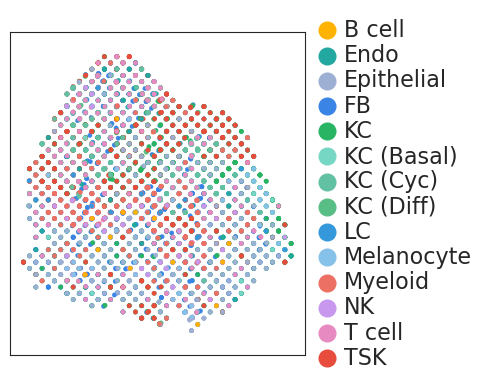

<Figure size 640x480 with 0 Axes>

In [15]:
pl.sc_celltype(refine_adata, color_map = major_color_map,tp_key = 'celltype_major', figsize= (3.8,4.2),
        legend = True, size = 10, alpha = 1, savefig = True)

In [16]:
# pl.sc_subtype(refine_adata,color_map = major_color_map,tp_key = 'celltype_major', savefig = True)

# 2. Spot Correlation

! pip install configargparse

In [18]:
before_spot_cor = eva.runSpotCor(before_adata, recon_exp_file = '',
                                 recon_meta_file = before_meta_fn,
               orig_sc_file = f'{Raw_inputDir}/SC_exp.tsv', orig_st_file = f'{Raw_inputDir}/ST_exp.tsv')

No exp file, Pull cells from original sc_exp


In [19]:
before_spot_cor.mean()

cor    0.734335
dtype: float64

In [20]:
refine_spot_cor = eva.runSpotCor(refine_adata, recon_exp_file = new_exp_fn,
                                 recon_meta_file = new_meta_fn,
               orig_sc_file = f'{Raw_inputDir}/SC_exp.tsv', orig_st_file = f'{Raw_inputDir}/ST_exp.tsv')


In [21]:
refine_spot_cor.mean()

cor    0.918566
dtype: float64

In [23]:
before_spot_cor['Method'] = 'Original'
refine_spot_cor['Method'] = 'Refined'
spot_cor = pd.concat([before_spot_cor,refine_spot_cor])

<Axes: ylabel='Spot correlation'>

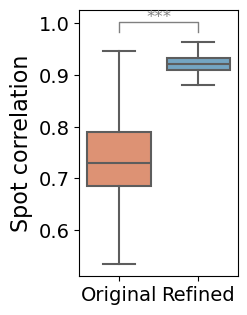

In [24]:
pl.boxplot(spot_cor,palette_dict = palette_dict,
                x='Method', y='cor',  ylabel='Spot correlation', 
                test = 't-test_ind',figsize=(2.4,3.4),savefig =refine_adata.uns['figpath'] + '/spot_cor.pdf')

# 3. AlphaTalk

## refine_adata

In [15]:
refine_adata

AnnData object with n_obs × n_vars = 7144 × 10659
    obs: 'sc_id', 'spot', 'exp_cor_before', 'interface_cor_before', 'mix_cor_before', 'exp_cor_after', 'interface_cor_after', 'mix_cor_after', 'celltype', 'UMAP1', 'UMAP2', 'st_x', 'st_y', 'spex_UMAP1', 'spex_UMAP2', 'indice', 'core1', 'core2', 'centering_scale_factor', 'adj_spex_UMAP1', 'adj_spex_UMAP2', 'celltype_major'
    var: 'symbol', 'MT_gene'
    uns: 'species', 'save_path', 'figpath', 'tp_key', 'major_color_map', 'rscript_path', 'python_path'

In [15]:
# Use AlphaTalk MAJOR-MAP results to generate CCI directly (14 major cell types).
alphatalk_refined_fp = '/bigdata/disk2/xtsong-data/strint/SCC_results/ana/alphatalk/major_map/tables/refined_lr_st_filter_major.csv'

In [16]:
draw_rec,draw_send = eva.generate_cci_alphatalk(
    refine_adata,
    alphatalk_path=alphatalk_refined_fp,
    sender_col='sender_major',
    receiver_col='receiver_major',
    return_df=True
)
load_alphatalk_major(
    refine_adata,
    '/bigdata/disk2/xtsong-data/strint/SCC_results/ana/alphatalk/major_map/tables/refined_lr_st_filter_major.csv',
    '/bigdata/disk2/xtsong-data/strint/SCC_results/ana/alphatalk/cci/refine'
)
# keep draw_send consistent with major-map CCI used by plotting
draw_send = refine_adata.uns['send_per'].copy()
draw_rec = refine_adata.uns['rec_per'].copy()
refine_adata.uns['spatalk_meta']=pd.DataFrame({'cell':refine_adata.obs.index.astype(str)},index=refine_adata.obs.index.astype(str))


In [17]:
draw_send

,B cell,Endo,Epithelial,FB,KC,KC (Basal),KC (Cyc),KC (Diff),LC,Melanocyte,Myeloid,NK,T cell,TSK
sender_tp,,,,,,,,,,,,,,
B cell,0.000000,0.095238,0.190476,0.666667,0.047619,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Endo,0.001200,0.000000,0.174565,0.110078,0.000000,0.121476,0.124475,0.000000,0.000000,0.011998,0.127774,0.012897,0.188962,0.126575
Epithelial,0.004819,0.190361,0.316466,0.139759,0.042972,0.046185,0.066667,0.000000,0.000000,0.029719,0.101205,0.008835,0.053012,0.000000
FB,0.032320,0.000000,0.121247,0.057755,0.055842,0.079174,0.090266,0.000000,0.000191,0.047237,0.131956,0.043794,0.258176,0.082042
KC,0.000000,0.000000,0.119797,0.162437,0.150254,0.000000,0.269036,0.076142,0.000000,0.084264,0.006091,0.000000,0.037563,0.094416
KC (Basal),0.000000,0.130758,0.086924,0.110327,0.097697,0.089153,0.113670,0.069837,0.002229,0.030089,0.090267,0.000000,0.072808,0.106241
KC (Cyc),0.000000,0.179070,0.000000,0.180814,0.000000,0.135465,0.152326,0.111047,0.000000,0.000000,0.000000,0.000000,0.080233,0.161047
KC (Diff),0.000000,0.000000,0.104079,0.000000,0.199719,0.000000,0.400844,0.120956,0.000000,0.000000,0.026723,0.000000,0.000000,0.147679
LC,0.000000,0.000000,0.000000,0.220930,0.430233,0.093023,0.011628,0.000000,0.000000,0.000000,0.244186,0.000000,0.000000,0.000000


In [18]:
sender_order = ['B cell','Myeloid','Melanocyte','NK',
                'TSK','T cell','KC', 'KC (Basal)', 'KC (Cyc)', 'KC (Diff)',
                'FB', 'Endo', 'Epithelial','LC']

4 6


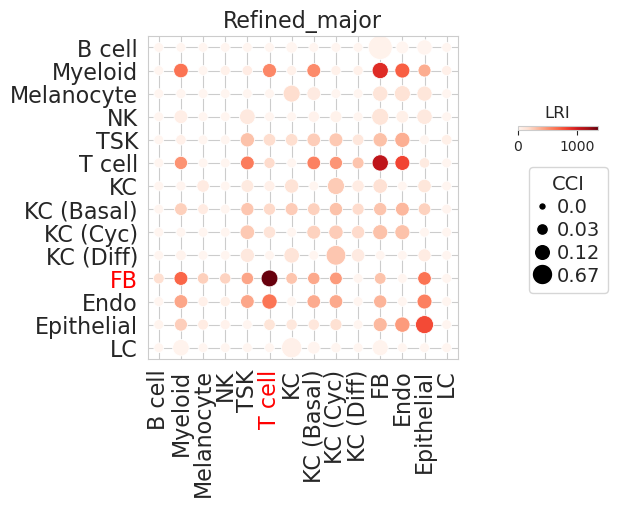

<Figure size 640x480 with 0 Axes>

In [41]:
import os, shutil
os.makedirs('/bigdata/disk2/xtsong-data/strint/SCC_results/ana/figures', exist_ok=True)
pl.celltype_cci(refine_adata, is_sender_per=True, figsize=(4,6),
            target_sender=sender_order, target_receiver=sender_order,
            y_highlight=['FB'], x_highlight=['T cell'],
            cmap='Reds', size='CCI', hue='LRI',
            savefig=True, color_bar_pos=[1.05, 0.38, 0.2, 0.35], title='Refined_major')
src='/bigdata/disk2/xtsong-data/strint/SCC_results/ana/figures/sender_CCI.pdf'
dst='/bigdata/disk2/xtsong-data/strint/SCC_results/ana/figures/sender_CCI_refined_major.pdf'
if os.path.exists(src):
    shutil.copyfile(src,dst)
draw_send.to_csv('/bigdata/disk2/xtsong-data/strint/SCC_results/ana/saved/refined/spa/CCI/draw_send_refined_major.csv')


## before

In [17]:
before_adata.uns['save_path'] = '/bigdata/disk2/xtsong-data/strint/SCC_results/ana/saved/before'
before_adata.uns['figpath'] = '/bigdata/disk2/xtsong-data/strint/SCC_results/ana/figures/'

In [18]:
# Use AlphaTalk MAJOR-MAP results to generate CCI directly (14 major cell types).
alphatalk_original_fp = '/bigdata/disk2/xtsong-data/strint/SCC_results/ana/alphatalk/major_map/tables/original_lr_st_filter_major.csv'


In [19]:
draw_rec,draw_send = eva.generate_cci_alphatalk(
    before_adata,
    alphatalk_path=alphatalk_original_fp,
    sender_col='sender_major',
    receiver_col='receiver_major',
    return_df=True
)
load_alphatalk_major(
    before_adata,
    '/bigdata/disk2/xtsong-data/strint/SCC_results/ana/alphatalk/major_map/tables/original_lr_st_filter_major.csv',
    '/bigdata/disk2/xtsong-data/strint/SCC_results/ana/alphatalk/cci/original'
)
draw_send = before_adata.uns['send_per'].copy()
draw_rec = before_adata.uns['rec_per'].copy()


In [22]:
sender_order = ['B cell','Myeloid','Melanocyte','NK',
                'TSK','T cell','KC', 'KC (Basal)', 'KC (Cyc)', 'KC (Diff)',
                'FB', 'Endo', 'Epithelial','LC']

4 6


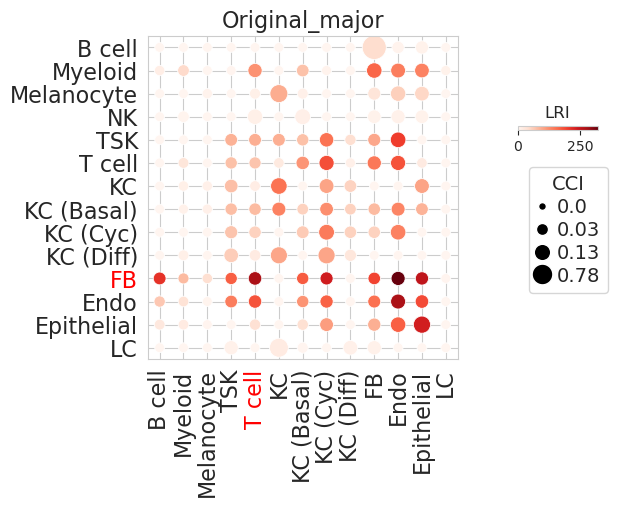

<Figure size 640x480 with 0 Axes>

In [46]:
import os, shutil
os.makedirs('/bigdata/disk2/xtsong-data/strint/SCC_results/ana/figures', exist_ok=True)
pl.celltype_cci(before_adata, is_sender_per=True, figsize=(4,6),
            target_sender=sender_order, target_receiver=sender_order,
            y_highlight=['FB'], x_highlight=['T cell'],
            cmap='Reds', size='CCI', hue='LRI',
            savefig=True, color_bar_pos=[1.05, 0.38, 0.2, 0.35], title='Original_major')
src='/bigdata/disk2/xtsong-data/strint/SCC_results/ana/figures/sender_CCI.pdf'
dst='/bigdata/disk2/xtsong-data/strint/SCC_results/ana/figures/sender_CCI_original_major.pdf'
if os.path.exists(src):
    shutil.copyfile(src,dst)
draw_send.to_csv('/bigdata/disk2/xtsong-data/strint/SCC_results/ana/saved/before/spa/CCI/draw_send_before_major.csv')


In [53]:
# import os
# os.makedirs('/bigdata/disk2/xtsong-data/strint/SCC_results/ana/saved/before/spa/CCI',exist_ok=True)
# draw_send.to_csv('/bigdata/disk2/xtsong-data/strint/SCC_results/ana/saved/before/spa/CCI/draw_send_before_major.csv')
# os.makedirs('/bigdata/disk2/xtsong-data/strint/SCC_results/ana/saved/refined/spa/CCI',exist_ok=True)
# refine_adata.uns['send_per'].to_csv('/bigdata/disk2/xtsong-data/strint/SCC_results/ana/saved/refined/spa/CCI/draw_send_refined_major.csv')


In [52]:
# # Compare Original vs Refined with shared color scale (major-cell CCI sender proportion)
# import os
# import matplotlib.pyplot as plt
# import seaborn as sns
# import numpy as np
# os.makedirs('/bigdata/disk2/xtsong-data/strint/SCC_results/ana/figures', exist_ok=True)

# major_order = ['B cell','Myeloid','Melanocyte','NK','TSK','KC','KC (Basal)','KC (Cyc)','KC (Diff)','FB','Endo','Epithelial','LC','T cell']
# orig = before_adata.uns['send_per'].copy()
# refi = refine_adata.uns['send_per'].copy()
# orig = orig.reindex(index=major_order, columns=major_order).fillna(0)
# refi = refi.reindex(index=major_order, columns=major_order).fillna(0)
# vmin = 0
# vmax = max(float(orig.to_numpy().max()), float(refi.to_numpy().max()))

# fig, axes = plt.subplots(1, 2, figsize=(10, 5), sharex=True, sharey=True)
# hm0 = sns.heatmap(orig, ax=axes[0], cmap='Reds', vmin=vmin, vmax=vmax, cbar=False, square=True)
# axes[0].set_title('Original (shared scale)', fontsize=12)
# axes[0].set_xlabel('Receiver major cell type')
# axes[0].set_ylabel('Sender major cell type')

# hm1 = sns.heatmap(refi, ax=axes[1], cmap='Reds', vmin=vmin, vmax=vmax, cbar=False, square=True)
# axes[1].set_title('Refined (shared scale)', fontsize=12)
# axes[1].set_xlabel('Receiver major cell type')
# axes[1].set_ylabel('')

# for ax in axes:
#     ax.tick_params(axis='x', labelrotation=60, labelsize=8)
#     ax.tick_params(axis='y', labelsize=8)

# # cbar = fig.colorbar(hm1.collections[0], ax=axes, fraction=0.025, pad=0.02)


# # 手动放置 colorbar（[left, bottom, width, height]，图坐标）
# fig.subplots_adjust(right=0.88)              # 给右侧腾位置
# cax = fig.add_axes([1.0, 0.18, 0.02, 0.64]) # 往右放
# cbar = fig.colorbar(hm1.collections[0], cax=cax)

# cbar.set_label('Sender proportion', fontsize=10)

# plt.tight_layout()
# out_fp='/bigdata/disk2/xtsong-data/strint/SCC_results/ana/figures/sender_CCI_original_vs_refined_shared_scale_major.pdf'
# plt.savefig(out_fp, bbox_inches='tight')
# plt.show()
# print('saved:', out_fp)


# 4. CCI

## 4.1 LRI overview of target cell types

In [20]:
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
colors = {'red': '#9DC5D8', 'white': '#F5DAC9', 'blue': '#DF7D97'}
# Create a list of tuples specifying the color map
colors_map = [(0.0, colors['red']), (0.5, colors['white']), (1.0, colors['blue'])]
# Create the colormap using LinearSegmentedColormap
cmap = LinearSegmentedColormap.from_list('my_colormap', colors_map)

### refine data

In [21]:
spa_res = refine_adata.uns['spatalk']
# t_mye_spa = spa_res[(spa_res['celltype_sender'] == 'T cell') & (spa_res['celltype_receiver'] == 'Myeloid')]
fb_t_plot = spa_res[(spa_res['celltype_sender'] == 'FB') & (spa_res['celltype_receiver'] == 'T cell')]

In [24]:
if len(fb_t_plot)>0:
    top_lig = fb_t_plot['ligand'].value_counts().head(20).index
    top_rec = fb_t_plot['receptor'].value_counts().head(20).index
    fb_t_plot = fb_t_plot[(fb_t_plot['ligand'].isin(top_lig)) & (fb_t_plot['receptor'].isin(top_rec))].copy()
else:
    top_lig=[]
    top_rec=[]
    fb_t_plot=fb_t_plot.copy()


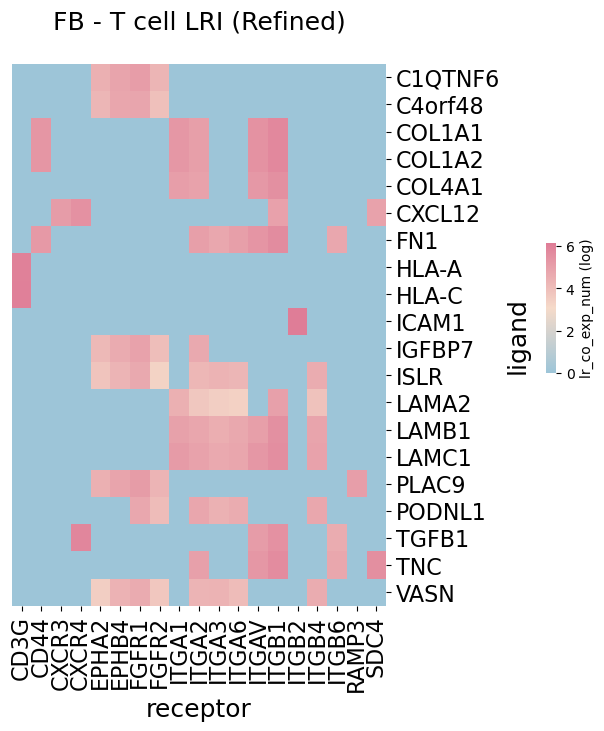

In [25]:
if len(fb_t_plot)>0:
    pl.clustermap(fb_t_plot, index='ligand', col='receptor', value='lr_co_exp_num', aggfunc='sum', log=True, scale=False, row_cluster=False, col_cluster=False, cmap=cmap, title='FB - T cell LRI (Refined)', rotate_x=True, xticks=True, yticks=True, xlabel=True, ylabel=True, cbar_x=1.1, figsize=(5,6.5), col_colors=None, row_colors=None, savefig=refine_adata.uns['figpath'] + 't_fb_alpha_heatmap_refined_1.pdf')

### original

In [26]:
def clustermap(df, index = 'ligand', col = 'receptor', value = 'lr_co_exp_num',
                 aggfunc = 'sum', log = True, scale = False, row_cluster = False, col_cluster = False,
                 highlight = None,  cmap = 'coolwarm', title = '', rotate_x = True,
                 xticks = False, yticks = True, xlabel = True, ylabel = True, cbar_x = 1.2,
                 figsize = (5,5),col_colors = None, row_colors = None,
                 savefig = False):
    '''
    df: dataframe
    if df has there columns and required to be pivot, then use the following parameters
    otherwise set aggfunc as None
        index: row index
        col: column index
        value: value to fill the pivot table
        aggfunc: how to aggregate the value
    log: log the value or not
    row_cluster: cluster row or not
    col_cluster: cluster column or not
    highlight: highlight the rows
    title: title of the plot
    cmap: color map of heatmap
    col_color: color of the column [sorted by the df row's order]
    xticks: show xticks or not
    yticks: show yticks or not
    savefig: output directory
    '''
    if aggfunc is None:
        n_tp_lri = df.copy()
    else:
        if aggfunc == 'sum':
            n_tp_lri = pd.crosstab(index=df[index], columns = df[col],values=df[value],aggfunc = sum)
    n_tp_lri = n_tp_lri.fillna(0)
    if log:
        n_tp_lri = np.log(n_tp_lri + 1)
        legend_label = f'{value} (log)'
    else:
        legend_label = f'{value}'

    if scale == True:
        n_tp_lri = n_tp_lri.apply(lambda x: (x - np.min(x)) / (np.max(x) - np.min(x)))
        
    clustermap = sns.clustermap(n_tp_lri,row_cluster=row_cluster,col_cluster=col_cluster,
               standard_scale=None,dendrogram_ratio=0.001,cmap = cmap, col_colors = col_colors,row_colors = row_colors,
               figsize=figsize, cbar_pos=(cbar_x, 0.5, 0.02, 0.2),cbar_kws={'orientation': 'vertical','label':legend_label})
    if not xticks:
        clustermap.ax_heatmap.set_xticklabels([])
        clustermap.ax_heatmap.set_xticks([])
    else:
        clustermap.ax_heatmap.xaxis.label.set_size(18)

        clustermap.ax_heatmap.set_xticklabels(
            clustermap.ax_heatmap.get_xticklabels(),
            rotation=90 if rotate_x else 0,
            fontsize=16
        )

    
    if not yticks:
        clustermap.ax_heatmap.set_yticklabels([])
        clustermap.ax_heatmap.set_yticks([])
    else:
        clustermap.ax_heatmap.yaxis.label.set_size(18)
        clustermap.ax_heatmap.set_yticklabels(
            clustermap.ax_heatmap.get_yticklabels(),
            rotation=90 if rotate_x else 0,
            fontsize=16
        )

    if not xlabel:
        clustermap.ax_heatmap.set_xlabel('')
    else:
        if xlabel != True:
            clustermap.ax_heatmap.set_xlabel(xlabel)
    if not ylabel:
        clustermap.ax_heatmap.set_ylabel('')
    else:
        if ylabel != True:
            clustermap.ax_heatmap.set_ylabel(ylabel)

    if highlight is not None:
        arr = n_tp_lri.index.to_list()
        if row_cluster:
            # Reorganize the index labels based on the cluster order
            reordered_index = [arr[i] for i in clustermap.dendrogram_row.reordered_ind]
            # Customize the ytick color and font weight
            yticks, _ = plt.yticks()
            ytick_labels = clustermap.ax_heatmap.get_yticklabels()
            for index, ytick_label in enumerate(ytick_labels):
                if reordered_index[index] in highlight:
                    ytick_label.set_color('red')
                    ytick_label.set_weight('bold')
        else:
            highlighted_ytick = np.where(np.isin(arr, highlight))[0]
            print(highlighted_ytick) # The ytick to be highlighted
            # Customize the ytick color
            _, yticks = plt.yticks()
            print(yticks)
            ytick_labels = clustermap.ax_heatmap.get_yticklabels()
            for index, ytick_label in enumerate(ytick_labels):
                if arr[index] in highlight:
                    ytick_label.set_color('red')
                    ytick_label.set_weight('bold')
    if title:
        clustermap.ax_heatmap.set_title(title,fontsize=18, y = 1.05) 

    if savefig:
        plt.savefig(f'{savefig}', bbox_inches='tight')

    # plt.xticks(fontsize=16)
    # plt.yticks(fontsize=16)

    # if rotate_x:
    #     # print('r')
    #     plt.xticks(fontsize=16, rotation=90)
    plt.show()

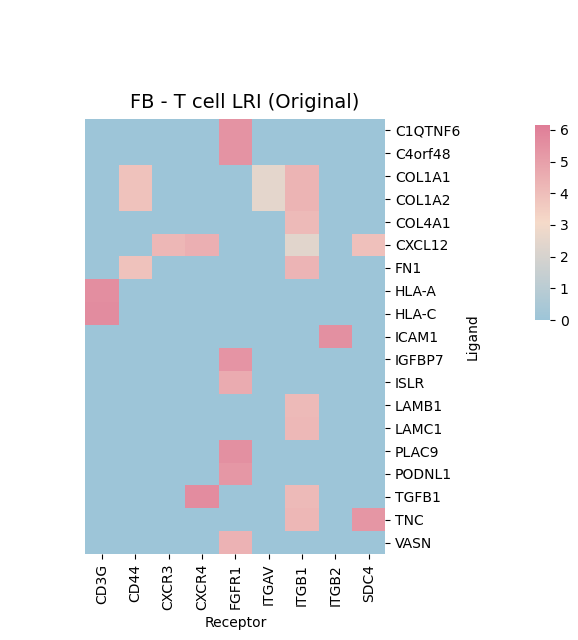

In [25]:
# before: use SAME LR set and SAME color scale as refined FB->T cell heatmap
spa_res_bef = before_adata.uns['spatalk']
fb_t_spa_bef = spa_res_bef[(spa_res_bef['celltype_sender'] == 'FB') & (spa_res_bef['celltype_receiver'] == 'T cell')].copy()
fb_t_spa_ref = refine_adata.uns['spatalk'][(refine_adata.uns['spatalk']['celltype_sender'] == 'FB') & (refine_adata.uns['spatalk']['celltype_receiver'] == 'T cell')].copy()

if 'lr_co_exp_num' not in fb_t_spa_bef.columns and 'co_exp_number' in fb_t_spa_bef.columns:
    fb_t_spa_bef['lr_co_exp_num'] = fb_t_spa_bef['co_exp_number']
if 'lr_co_exp_num' not in fb_t_spa_ref.columns and 'co_exp_number' in fb_t_spa_ref.columns:
    fb_t_spa_ref['lr_co_exp_num'] = fb_t_spa_ref['co_exp_number']

if 'top_lig' in globals() and 'top_rec' in globals() and len(top_lig)>0 and len(top_rec)>0:
    fb_t_plot_ref = fb_t_spa_ref[(fb_t_spa_ref['ligand'].isin(top_lig)) & (fb_t_spa_ref['receptor'].isin(top_rec))].copy()
    fb_t_plot_bef = fb_t_spa_bef[(fb_t_spa_bef['ligand'].isin(top_lig)) & (fb_t_spa_bef['receptor'].isin(top_rec))].copy()
else:
    fb_t_plot_ref = fb_t_spa_ref.copy()
    fb_t_plot_bef = fb_t_spa_bef.copy()

import numpy as np, pandas as pd, seaborn as sns, matplotlib.pyplot as plt
ref_mat = pd.crosstab(index=fb_t_plot_ref['ligand'], columns=fb_t_plot_ref['receptor'], values=fb_t_plot_ref['lr_co_exp_num'], aggfunc=sum).fillna(0)
ref_mat = np.log(ref_mat + 1)
vmin = float(ref_mat.values.min()) if ref_mat.size>0 else 0.0
vmax = float(ref_mat.values.max()) if ref_mat.size>0 else 1.0

if len(fb_t_plot_bef) > 0:
    bef_mat = pd.crosstab(index=fb_t_plot_bef['ligand'], columns=fb_t_plot_bef['receptor'], values=fb_t_plot_bef['lr_co_exp_num'], aggfunc=sum).fillna(0)
    bef_mat = np.log(bef_mat + 1)
    cg = sns.clustermap(bef_mat, cmap=cmap, vmin=vmin, vmax=vmax, row_cluster=False, col_cluster=False, figsize=(5,6.5), cbar_pos=(1.08,0.5,0.03,0.3))
    plt.suptitle('FB - T cell LRI (Original)', y=0.85, fontsize=14)
    cg.ax_heatmap.set_xlabel('Receptor')
    cg.ax_heatmap.set_ylabel('Ligand')
    plt.savefig(before_adata.uns['figpath'] + 't_fb_alpha_heatmap_original_sameLR.pdf', bbox_inches='tight')
    plt.show()
else:
    print('No FB->T cell interactions after applying refined top_lig/top_rec filter in original data.')


## 4.2 KEGG

对于上面的T- Myeloid细胞通讯，进行enrich

In [23]:
kegg_enrich = eva.runKEGG(refine_adata, rscript_executable=None, input_df=fb_t_plot, df_name='fb_t_cell')

/home/xtsong/miniforge3/envs/strint_3/lib/R/bin/R: line 8: uname: command not found
/home/xtsong/miniforge3/envs/strint_3/lib/R/etc/ldpaths: line 12: uname: command not found
Warning message:
package ‘clusterProfiler’ was built under R version 4.2.2 
Warning messages:
1: package ‘AnnotationDbi’ was built under R version 4.2.2 
2: package ‘BiocGenerics’ was built under R version 4.2.1 
3: package ‘Biobase’ was built under R version 4.2.3 
4: package ‘IRanges’ was built under R version 4.2.3 
5: package ‘S4Vectors’ was built under R version 4.2.3 


[1] "fb_t_cell_kegg.tsv"


'select()' returned 1:1 mapping between keys and columns


fb_t_cell


sh: rm: command not found


In [28]:
# skipped in automated rerun due unavailable external dependency or malformed exploratory snippet
kegg_enrich.to_csv('/bigdata/disk2/xtsong-data/strint/SCC_results/ana/saved/kegg/fb_t_kegg_final.csv')

In [26]:
kegg_enrich = pd.read_csv('/bigdata/disk2/xtsong-data/strint/SCC_results/ana/saved/kegg/fb_t_kegg_final.csv')

In [31]:
# skipped in automated rerun due unavailable external dependency or malformed exploratory snippet
top_pathway_df = (
    kegg_enrich
    .sort_values('p.adjust')
    .head(4)
)

top_pathways = top_pathway_df['Description'].tolist()  
top_pathways

['ECM-receptor interaction',
 'Integrin signaling',
 'PI3K-Akt signaling pathway',
 'Focal adhesion']

In [43]:
# skipped in automated rerun due unavailable external dependency or malformed exploratory snippet
# 【第2步】为每个通路提取基因列表                                                                                                             
pathway_genes = {}
for idx, row in top_pathway_df.iterrows():                                                                                                    
    pathway = row['Description']                                                                                                              
    genes = str(row['geneSymbol']).split('/')
    genes = [g.strip() for g in genes if g.strip()]                                                                                           
    pathway_genes[pathway] = genes                                                                                                            

# 【第3步】构建L-R-通路子集                                                                                                                   
lr_pathway_subset = []

for pathway in top_pathways:                                                                                                                  
    genes_in_pathway = pathway_genes[pathway]
                                                                                                                                            
    # 从tsk_fb_spa中找这个通路中的基因作为ligand                                                                                              
    pathway_ligands = fb_t_plot[fb_t_plot['ligand'].isin(genes_in_pathway)]
                                                                                                                                            
    if len(pathway_ligands) > 0:                                                                                                              
        # 选择表达量最高的1-2个ligand
        top_ligands = pathway_ligands.nlargest(2, 'lr_co_exp_num')['ligand'].unique()                                                         
                                                                                                                                            
        # 对于每个ligand，选择表达量最高的1-2个receptor                                                                                       
        for ligand in top_ligands:                                                                                                            
            ligand_receptors = pathway_ligands[pathway_ligands['ligand'] == ligand]                                                           
            top_receptors = ligand_receptors.nlargest(2, 'lr_co_exp_num')                                                                     

            for _, row in top_receptors.iterrows():                                                                                           
                lr_pathway_subset.append({
                    'ligand': row['ligand'],                                                                                                  
                    'receptor': row['receptor'],
                    'pathway': pathway
                })

# 【第4步】转为DataFrame                                                                                                                      
lr_path_df = pd.DataFrame(lr_pathway_subset)

In [33]:
lr_path_df

,ligand,receptor,pathway
0,COL1A1,ITGB1,ECM-receptor interaction
1,COL1A1,ITGA2,ECM-receptor interaction
2,COL1A1,ITGB1,ECM-receptor interaction
3,COL1A1,ITGAV,ECM-receptor interaction
4,COL1A2,ITGB1,ECM-receptor interaction
5,COL1A2,ITGA2,ECM-receptor interaction
6,COL1A2,ITGB1,ECM-receptor interaction
7,COL1A2,ITGAV,ECM-receptor interaction
8,FN1,ITGA6,ECM-receptor interaction
9,FN1,ITGB1,ECM-receptor interaction


In [44]:
# skipped in automated rerun due unavailable external dependency or malformed exploratory snippet
pl.draw_lr_flow3(lr_path_df,
                left_panel='ligand',                                                                                                         
                mid_panel='receptor',
                right_panel='pathway',                                                                                                       
                figsize=(10,12), outDir='/bigdata/disk2/xtsong-data/strint/SCC_results/ana/kegg/kegg_1.pdf')

# 5. Selected LRI COL1A1-ITGA2

In [35]:
np.unique(np.array(refine_adata.obs['celltype']))

array(['B Cell', 'CD1C', 'CD4_Naive', 'CD4_Pre_Exh', 'CD8_EM', 'CD8_Exh',
       'CLEC9A', 'Eccrine', 'Endothelial Cell', 'Fibroblast',
       'Keratinocyte', 'LC', 'MDSC', 'Mac', 'Melanocyte', 'Mig_CD1C',
       'Mig_CLEC9A', 'Mig_LC', 'NK', 'PDC', 'Pilosebaceous', 'TSK',
       'Treg', 'Tumor_KC_Basal', 'Tumor_KC_Cyc', 'Tumor_KC_Diff'],
      dtype=object)

In [36]:
sender = 'FB'
receiver = 'T cell'
ligand = 'COL1A1'
receptor = 'ITGA2'
print(f'{sender} to {receiver} {ligand} to {receptor}')

FB to T cell COL1A1 to ITGA2


In [40]:
def build_cellpair_from_spot(
    adata,
    sender_mask,
    receiver_mask,
    sender_tp_value,
    receiver_tp_value,
    max_pairs_per_spot=30
):
    obs = adata.obs.copy()
    obs = obs[['st_x', 'st_y']].copy()
    obs['cell_id'] = obs.index.astype(str)
    obs['spot_key'] = obs['st_x'].astype(str) + '|' + obs['st_y'].astype(str)

    sender_cells = obs.loc[sender_mask].copy()
    receiver_cells = obs.loc[receiver_mask].copy()
    pair_rows = []
    for spot_key, s_df in sender_cells.groupby('spot_key'):
        if spot_key not in receiver_cells['spot_key'].values:
            continue
        r_df = receiver_cells[receiver_cells['spot_key'] == spot_key]
        if len(r_df) == 0:
            continue
        cnt = 0
        for s_id in s_df['cell_id'].tolist():
            for r_id in r_df['cell_id'].tolist():
                pair_rows.append({
                    'cell_sender': s_id,
                    'cell_receiver': r_id,
                    'sender_tp': sender_tp_value,
                    'receiver_tp': receiver_tp_value,
                })
                cnt += 1
                if cnt >= max_pairs_per_spot:
                    break
            if cnt >= max_pairs_per_spot:
                break
    cp = pd.DataFrame(pair_rows)
    if len(cp) > 0:
        cp['Name'] = cp['sender_tp'].astype(str) + ' -- ' + cp['receiver_tp'].astype(str)
    return cp


Figure saved /bigdata/disk2/xtsong-data/strint/SCC_results/ana/figures//FB_T cell_COL1A1_T cell_arrow.pdf


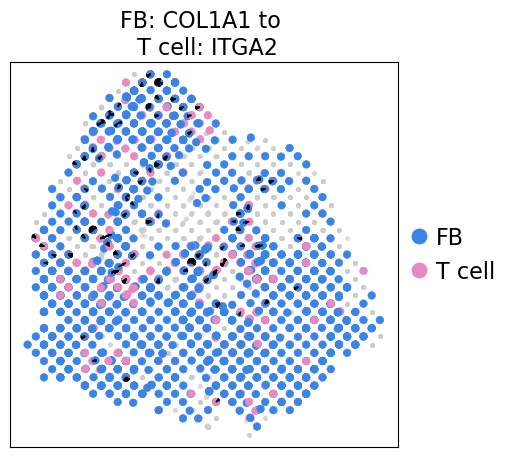

In [41]:
# 1) major-level FB -> T cell
major_cp = build_cellpair_from_spot(
    refine_adata,
    refine_adata.obs['celltype_major'].astype(str) == sender,
    refine_adata.obs['celltype_major'].astype(str) == receiver,
    sender,
    receiver,
    max_pairs_per_spot=40
)
if len(major_cp) == 0:
    raise RuntimeError('No major-level FB->T cell cell pairs found on shared spots for LRI plotting.')
refine_adata.uns['cellpair'] = major_cp
pl.LRI_of_CCI(
    refine_adata,
    sender=sender,
    receiver=receiver,
    ligand=ligand,
    receptor=receptor,
    subset=False,
    show_pair=False,
    hue='celltype_major',
    color_map=major_color_map,
    figsize=(5, 5),
    arrow_length=0.5,
    size=30,
    savefig=True
)
